In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal

from wattson.models.power_supply import Battery
from wattson.models.database import Database

In [2]:
# battery = Battery()
database = Database()

In [3]:
df = database.get_data()

/home/tortugellini/git/wattson/src/wattson/models/database.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(f"SELECT * FROM {self.database}", con=self.connection)


In [4]:
df['cpu_temp'] = df['cpu_temp'] / 10**3 # Converting milli-Fahrenheit to Fahrenheit.
df['wifi_temp'] = df['wifi_temp'] / 10**3 # Converting milli-Fahrenheit to Fahrenheit.

In [5]:
df["time"] = df['time'].astype("float64")

In [6]:
df["time"] = df["time"] / 1000 # Converting from milliseconds to seconds.

In [7]:
df.set_index("time", inplace=True)

In [8]:
power_mask = df['power'] == 0
df = df.mask(power_mask)

In [9]:
plot_data = df['energy'][df.index > 1.7536e9 + 85000]
plot_data = plot_data[~np.isnan(plot_data)]

In [10]:
plot_data = plot_data / 10**6 # Converting from nanojoules to milljoules.

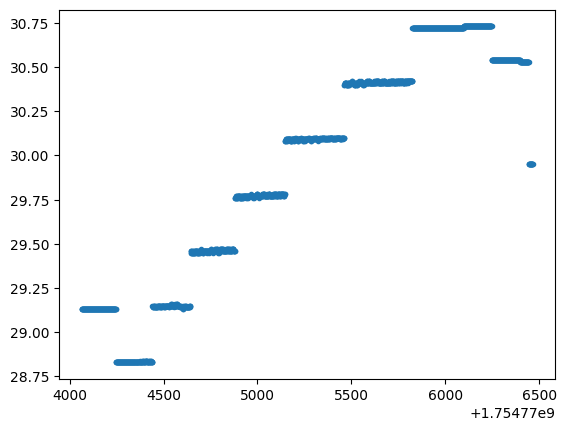

In [11]:
plt.plot(plot_data, '.')

In [27]:
diff_data = plot_data.to_numpy(dtype=float)
diff = np.diff(diff_data)
diff_mask = abs(diff) > .1
diff_mask = np.insert(diff_mask, 0, True)
diff_mask = np.where(diff_mask)[0]

In [29]:
test_data = plot_data.iloc[diff_mask[1]:diff_mask[2]]

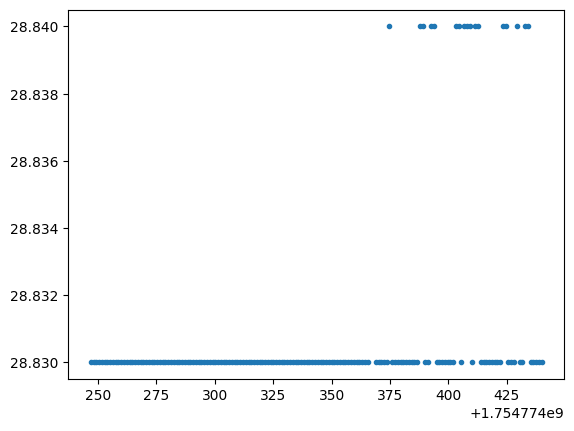

In [30]:
plt.plot(test_data, '.')

In [48]:
def gaussian(x, x0, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(1/2) * (x-x0)**2 / sigma**2)
quotient = gaussian(np.linspace(0,5,6), 3, 6000)
recovered, remainder = scipy.signal.deconvolve(test_data, quotient)

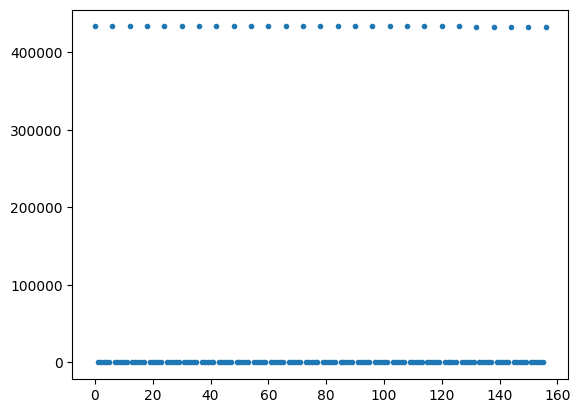

In [49]:
plt.plot(recovered, '.')

In [ ]:
# TODO: Make object to hold and handle chemical reactions, thermodynamic quantities, and perform thermodynamic calculations.
# TODO: Fix database so it uses SQLAlchemy.